# Modhav Benchmark

Modhav dataset has to yield:
- 0.5 accuracy in classical kernel 
- 1.0 accuracy in quantum kernel (kta) $\rightarrow$ done
- 1.0 accuracy in quantum kernel (geometric)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from config.config import *
from config.experiments import ExperimentConfig
from src.data.saving import svm_exists, load_parameter_train
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.data.synthetic import *
from src.utils.visuals import *
from src.optimization.classical_base import classical_benchmark

from src.data.preprocessing import preprocess_synthetic

RESULTS_DIR = 'Results/ModHav Benchmark'

## 0. Classical Performance

In [5]:
deltas = np.linspace(0.1, 0.3, 10)
accuracies_classical, errs_classical = [], []

for delta in deltas:
    accs = []
    for seed in range(9):
        X, y = ModHav_synthetic_dataset(delta=delta, seed=seed)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y)
        results = classical_benchmark(X_train, y_train, X_test, y_test)
        accs.append(results['accuracy'])
    accuracies_classical.append(np.mean(accs))
    errs_classical.append(np.std(accs))

data = {'deltas': deltas, 'accuracies_classical': accuracies_classical, 'errs_classical': errs_classical}
df = pd.DataFrame(data)
df.to_csv('Results/ModHav Benchmark/ClassicalPerformance.csv', index=False)

In [ ]:
candidate, _ = find_hard_generating_candidate()
accuracies_classical_h, errs_classical_h = [], []
deltas_h = np.linspace(0.1, 0.22, 5)
for delta in deltas_h:
    accs = []
    for seed in range(9):
        X, y = ModHav_synthetic_dataset(delta=delta, seed=seed, enc_candidate=candidate)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y)
        results = classical_benchmark(X_train, y_train, X_test, y_test)
        accs.append(results['accuracy'])
    accuracies_classical_h.append(np.mean(accs))
    errs_classical_h.append(np.std(accs))

data = {'deltas': deltas, 'accuracies_classical': accuracies_classical, 'errs_classical': errs_classical}
df = pd.DataFrame(data)
df.to_csv('Results/ModHav Benchmark/ClassicalPerformance.csv', index=False)

In [10]:
data = {'deltas_h': deltas_h, 'accuracies_classical_h':accuracies_classical_h, 'errs_classical_h': errs_classical_h}
df = pd.DataFrame(data)
df.to_csv('Results/ModHav Benchmark/ClassicalPerformanceHard.csv', index=False)

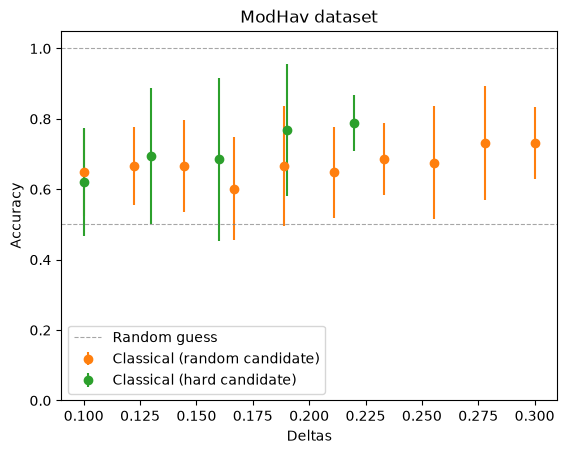

In [ ]:
plt.title('ModHav dataset')
plt.errorbar(deltas, accuracies_classical, yerr=errs_classical, label='Classical (random candidate)', color='tab:orange', fmt='o')
plt.errorbar(deltas_h, accuracies_classical_h, yerr=errs_classical_h, label='Classical (hard candidate)', color='tab:green', fmt='o')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend()
plt.ylim(0, 1.05)
plt.show()

## 1. Quantum KTA Performance

In [ ]:
deltas = np.linspace(0.1, 0.6, 5)
accuracies_kta, errs_kta = [], []

config = ExperimentConfig(
    name='',
    optimizer='optuna',
    variant='kta',
    subset_method='none',
    optimizer_kwargs={'n_trials': N_TRIALS},
)

for delta in deltas:
    accs = []
    for seed in range(3):
        config.name=f'Results/ModHav Benchmark/optuna 100 d{delta} s{seed}'
        X, y = ModHav_synthetic_dataset(seed=seed, delta=delta)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)
        
        trained_candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
        g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))
        
        K_test = None
        if not svm_exists(config.name):
            print("Computing cross-kernel (test × subset)…")
            K_test = quantum_kernel_matrix_cross(X_test, X_sub, trained_candidate)
        results = get_svm_results(config, K_train, y_sub, K_test, y_test)
        accs.append(results['accuracy'])
        
        unique, counts = np.unique(results['y_pred'], return_counts=True)
        print(f"delta= {delta} seed={seed}: acc={results['accuracy']:.3f}, predicted counts={dict(zip(unique, counts))}")
    accuracies_kta.append(np.mean(accs))
    errs_kta.append(np.std(accs))

[I 2026-08-27 14:21:25,322] A new study created in memory with name: no-name-4da1db2d-8a50-4221-bbf1-464c12f4ef1e
[I 2026-08-27 14:21:27,945] Trial 0 finished with value: 0.21696484839534685 and parameters: {'gate_0': 'H', 'angle_0': 2.3626135061580507, 'gate_1': 'CNOT', 'angle_1': 3.3961632323185076, 'gate_2': 'RX', 'angle_2': 3.399079416774549, 'gate_3': 'CNOT', 'angle_3': 5.1290415104999285, 'gate_4': 'RY', 'angle_4': 2.4119629883830056, 'gate_5': 'RX', 'angle_5': 6.220520030708168, 'gate_6': 'I', 'angle_6': 1.7442631157115573, 'gate_7': 'H', 'angle_7': 3.6445911969609432, 'gate_8': 'H', 'angle_8': 3.718154189019024, 'gate_9': 'RY', 'angle_9': 1.5005152150878438, 'gate_10': 'CNOT', 'angle_10': 0.4262912394805385, 'gate_11': 'RY', 'angle_11': 2.7244070657073034, 'gate_12': 'RY', 'angle_12': 1.7532421231392425, 'gate_13': 'RZ', 'angle_13': 5.883626974579716, 'gate_14': 'RX', 'angle_14': 2.964849505037292, 'gate_15': 'RZ', 'angle_15': 0.4233872972834224}. Best is trial 0 with value: 0.

Saved candidate  → Results/optuna 100 d0.1 s0/candidate.pkl
Computing cross-kernel (test × subset)…
Saved SVM        → Results/optuna 100 d0.1 s0/svm.pkl

REPORT: optuna 100 d0.1 s0 | 100 trials
Best C            : 1
Best CV accuracy  : 0.9167
Test accuracy     : 0.7500
              precision    recall  f1-score   support

          -1       0.71      0.83      0.77         6
           1       0.80      0.67      0.73         6

    accuracy                           0.75        12
   macro avg       0.76      0.75      0.75        12
weighted avg       0.76      0.75      0.75        12

delta= 0.1 seed=0: acc=0.750, predicted counts={-1: 7, 1: 5}


[I 2026-08-27 14:26:26,507] A new study created in memory with name: no-name-34b58edc-e6d6-491f-8837-ebbaaedd88a4
[I 2026-08-27 14:26:28,802] Trial 0 finished with value: 0.07216249498365601 and parameters: {'gate_0': 'RZ', 'angle_0': 1.1914071759723937, 'gate_1': 'I', 'angle_1': 1.7100159541764022, 'gate_2': 'RX', 'angle_2': 5.082638398068156, 'gate_3': 'RZ', 'angle_3': 5.262391431388965, 'gate_4': 'RZ', 'angle_4': 2.2027285012232545, 'gate_5': 'I', 'angle_5': 5.188360493735253, 'gate_6': 'I', 'angle_6': 3.378298782479323, 'gate_7': 'CNOT', 'angle_7': 2.64753246598672, 'gate_8': 'H', 'angle_8': 1.0353939392984333, 'gate_9': 'RY', 'angle_9': 0.511298651559611, 'gate_10': 'H', 'angle_10': 1.6835552366765503, 'gate_11': 'CNOT', 'angle_11': 0.31934457957877754, 'gate_12': 'CNOT', 'angle_12': 6.132410919240878, 'gate_13': 'CNOT', 'angle_13': 5.022901529176707, 'gate_14': 'I', 'angle_14': 5.321926834479572, 'gate_15': 'I', 'angle_15': 4.576758469666512}. Best is trial 0 with value: 0.072162

Saved candidate  → Results/optuna 100 d0.1 s1/candidate.pkl
Computing cross-kernel (test × subset)…
Saved SVM        → Results/optuna 100 d0.1 s1/svm.pkl

REPORT: optuna 100 d0.1 s1 | 100 trials
Best C            : 0.1
Best CV accuracy  : 0.8167
Test accuracy     : 0.6667
              precision    recall  f1-score   support

          -1       0.62      0.83      0.71         6
           1       0.75      0.50      0.60         6

    accuracy                           0.67        12
   macro avg       0.69      0.67      0.66        12
weighted avg       0.69      0.67      0.66        12

delta= 0.1 seed=1: acc=0.667, predicted counts={-1: 8, 1: 4}


[I 2026-08-27 14:31:14,039] A new study created in memory with name: no-name-0be737bf-2972-49ab-8188-91a808ec98f2
[I 2026-08-27 14:31:16,460] Trial 0 finished with value: 0.1643401829752949 and parameters: {'gate_0': 'H', 'angle_0': 1.720863400174179, 'gate_1': 'RY', 'angle_1': 1.516434197921676, 'gate_2': 'RZ', 'angle_2': 1.3827400421781222, 'gate_3': 'RY', 'angle_3': 1.869178371413458, 'gate_4': 'I', 'angle_4': 1.4290222181837782, 'gate_5': 'CNOT', 'angle_5': 5.602439300225624, 'gate_6': 'RX', 'angle_6': 6.069664476476153, 'gate_7': 'RZ', 'angle_7': 2.4521381612177597, 'gate_8': 'H', 'angle_8': 0.42701875191204536, 'gate_9': 'I', 'angle_9': 0.5224097524207013, 'gate_10': 'RY', 'angle_10': 2.274262803748539, 'gate_11': 'RZ', 'angle_11': 2.5643005352311747, 'gate_12': 'RY', 'angle_12': 0.6723246241394607, 'gate_13': 'I', 'angle_13': 5.280871840406062, 'gate_14': 'RY', 'angle_14': 0.12769331697153619, 'gate_15': 'RY', 'angle_15': 0.06892682211000503}. Best is trial 0 with value: 0.16434

...

[I 2026-08-27 14:52:40,525] A new study created in memory with name: no-name-7e5e5455-2a7a-4d23-8105-9527cc42beda
[I 2026-08-27 14:52:42,511] Trial 0 finished with value: 0.12077178733186796 and parameters: {'gate_0': 'CNOT', 'angle_0': 2.8107578696837168, 'gate_1': 'I', 'angle_1': 1.8159337367585886, 'gate_2': 'I', 'angle_2': 1.8318342660850986, 'gate_3': 'RX', 'angle_3': 5.711454028706084, 'gate_4': 'CNOT', 'angle_4': 5.982403362276365, 'gate_5': 'I', 'angle_5': 3.3852787663164348, 'gate_6': 'RX', 'angle_6': 5.734150513945021, 'gate_7': 'CNOT', 'angle_7': 0.5474787092096163, 'gate_8': 'RX', 'angle_8': 2.699361369862664, 'gate_9': 'CNOT', 'angle_9': 0.8371451769058278, 'gate_10': 'I', 'angle_10': 0.31930879672794055, 'gate_11': 'RY', 'angle_11': 2.3536177029686436, 'gate_12': 'RY', 'angle_12': 1.0965337533393456, 'gate_13': 'I', 'angle_13': 5.15292648739831, 'gate_14': 'RZ', 'angle_14': 2.7896306458233426, 'gate_15': 'I', 'angle_15': 4.190889172355525}. Best is trial 0 with value: 0.1

Saved candidate  → Results/optuna 100 d0.35 s1/candidate.pkl
Computing cross-kernel (test × subset)…
Saved SVM        → Results/optuna 100 d0.35 s1/svm.pkl

REPORT: optuna 100 d0.35 s1 | 100 trials
Best C            : 0.1
Best CV accuracy  : 0.9667
Test accuracy     : 0.9167
              precision    recall  f1-score   support

          -1       0.86      1.00      0.92         6
           1       1.00      0.83      0.91         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12

delta= 0.35 seed=1: acc=0.917, predicted counts={-1: 7, 1: 5}


[I 2026-08-27 14:56:50,861] A new study created in memory with name: no-name-cc5321bf-01e9-4fa2-ac51-ff84e5760920
[I 2026-08-27 14:56:53,229] Trial 0 finished with value: 0.16436982939592362 and parameters: {'gate_0': 'H', 'angle_0': 3.737244198582982, 'gate_1': 'I', 'angle_1': 4.0401311236400455, 'gate_2': 'CNOT', 'angle_2': 2.8346718276038954, 'gate_3': 'RY', 'angle_3': 0.5971437217804458, 'gate_4': 'RZ', 'angle_4': 5.5367644364332005, 'gate_5': 'RZ', 'angle_5': 2.296857718878405, 'gate_6': 'RX', 'angle_6': 5.478302337800852, 'gate_7': 'CNOT', 'angle_7': 4.724720423822937, 'gate_8': 'RY', 'angle_8': 5.068112482857474, 'gate_9': 'RZ', 'angle_9': 3.8859724692114423, 'gate_10': 'H', 'angle_10': 0.7116123456193792, 'gate_11': 'CNOT', 'angle_11': 0.7547741453411811, 'gate_12': 'H', 'angle_12': 2.1438075889766246, 'gate_13': 'RY', 'angle_13': 1.5514863668146455, 'gate_14': 'RY', 'angle_14': 1.0484148102765642, 'gate_15': 'I', 'angle_15': 3.2215204071072723}. Best is trial 0 with value: 0.1

Saved candidate  → Results/optuna 100 d0.35 s2/candidate.pkl
Computing cross-kernel (test × subset)…
Saved SVM        → Results/optuna 100 d0.35 s2/svm.pkl

REPORT: optuna 100 d0.35 s2 | 100 trials
Best C            : 0.1
Best CV accuracy  : 0.9500
Test accuracy     : 0.8333
              precision    recall  f1-score   support

          -1       0.83      0.83      0.83         6
           1       0.83      0.83      0.83         6

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12

delta= 0.35 seed=2: acc=0.833, predicted counts={-1: 6, 1: 6}


RuntimeError: delta=0.475 too high, only got {1: 0, -1: 3} after 20001 tries

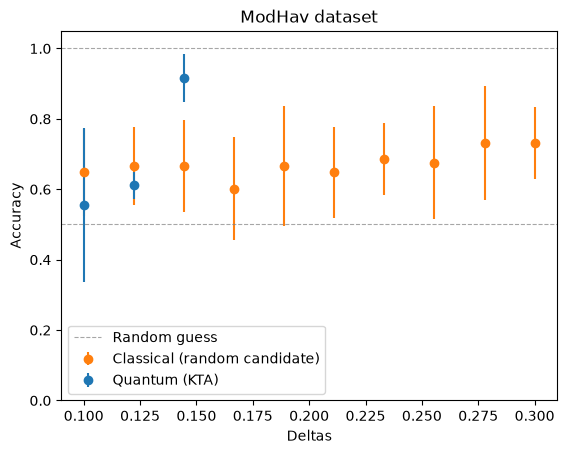

In [20]:
deltas = np.linspace(0.1, 0.3, 10)
plt.title('ModHav dataset')
plt.errorbar(deltas, accuracies_classical, yerr=errs_classical, label='Classical (random candidate)', color='tab:orange', fmt='o')
plt.errorbar(deltas[:len(accuracies_kta)], accuracies_kta, yerr=errs_kta, label='Quantum (KTA)', color='tab:blue', fmt='o')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend()
plt.ylim(0, 1.05)
plt.show()